# Lab 1: Ensembles
Yulieth Natalia Fajardo (301382590)

May 13, 2025

# Chapter 13: Combining Models: Ensembles and Uplift Modeling

> (c) 2019 Galit Shmueli, Peter C. Bruce, Peter Gedeck
>
> Code included in
>
> _Data Mining for Business Analytics: Concepts, Techniques, and Applications in Python_ (First Edition)
> Galit Shmueli, Peter C. Bruce, Peter Gedeck, and Nitin R. Patel. 2019.

## Import required packages

In [41]:
%matplotlib inline

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.metrics import classification_report

!pip install dmba
from dmba import classificationSummary

!pip install skimpy
from skimpy import skim


Create a classification model to predict Personal Loan Outcomes using the following models:

1. Decision Tree
2. Random Forest
3. Boosting
4. Bagging
5. Gradient Boosting
6. rf with hyperparameter tuning


## Data Prep

In [42]:
# Load dataset
df = pd.read_csv('UniversalBank.csv')
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [43]:
# Inspect
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 5000   │ │ int64       │ 13    │                                                          │
│ │ Number of columns │ 14     │ │ float64     │ 1     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                ┃ NA  ┃ NA %  ┃ mean    ┃ sd      ┃ p0    ┃ p25    ┃ p50    ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ ID                    │   0 │     0 │    2500 │    1444 │     1 │   1251 │   2500 │  3750 │  5000 │ ██████ │  │
│ │ Age                   │   0 │     0 │   45.34 │   11.46 │    23 │     35 │     45 │    55 │    67 │ ▅▇▇█▇▅ │  │
│ │ Experience            │   0 │     0 │    20.1 │   11.47 │    -3 │     10 │     20 │    30 │    43 │ ▄▇▇██▄ │  │
│ │ Income                │   0 │     0 │   73.77 │   46.03 │     8 │     39 │     64 │    98 │   224 │ █▇▅▂▂  │  │
│ │ ZIP Code              │   0 │     0 │   93150 │    2122 │  9307 │  91910 │  93440 │ 94610 │ 96650 │      █ │  │
│ │ Family                │   0 │     0 │   2.396 │   1.148 │     1 │      1 │      2 │     3 │     4 │ █ ▇ ▅▇ │  │
│ │ CCAvg                 │   0 │     0 │   1.938 │   1.748 │     0 │    0.7 │    1.5 │   2.5 │    10 │  █▅▁▁  │  │
│ │ Education             │   0 │     0 │   1.881 │  0.8399 │     1 │      1 │      2 │     3 │     3 │ █  ▅ ▆ │  │
│ │ Mortgage              │   0 │     0 │    56.5 │   101.7 │     0 │      0 │      0 │   101 │   635 │  █▂▁   │  │
│ │ Personal Loan         │   0 │     0 │   0.096 │  0.2946 │     0 │      0 │      0 │     0 │     1 │ █    ▁ │  │
│ │ Securities Account    │   0 │     0 │  0.1044 │  0.3058 │     0 │      0 │      0 │     0 │     1 │ █    ▁ │  │
│ │ CD Account            │   0 │     0 │  0.0604 │  0.2383 │     0 │      0 │      0 │     0 │     1 │ █    ▁ │  │
│ │ Online                │   0 │     0 │  0.5968 │  0.4906 │     0 │      0 │      1 │     1 │     1 │ ▅    █ │  │
│ │ CreditCard            │   0 │     0 │   0.294 │  0.4556 │     0 │      0 │      0 │     1 │     1 │ █    ▃ │  │
│ └───────────────────────┴─────┴───────┴─────────┴─────────┴───────┴────────┴────────┴───────┴───────┴────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [44]:
# Determine whether are null values
df.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIP Code,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal Loan,0


We have to take care with the results of this model because there is a class imbalance that can lead to potential overfitting issues if taken as-is.


In [45]:
# Count of prediction classes
print(df['Personal Loan'].value_counts() / len(df))

Personal Loan
0    0.904
1    0.096
Name: count, dtype: float64


In [46]:
# Data Split
X = df.drop(columns='Personal Loan')
y = df['Personal Loan']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=301382590)

I will oversample my datset by using SMOTE

In [47]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=301382590)
X_res, y_res = sm.fit_resample(X_train, y_train)

## Ensemble

### single tree

In [48]:
# Define a base regressor (Decision Tree)
single_tree_clf = DecisionTreeClassifier(random_state=301382590)
# Train model
# single_tree_clf.fit(X_train, y_train)
single_tree_clf.fit(X_res, y_res)
# Predict single tree
y_pred_single = single_tree_clf.predict(X_test)



# Evaluate with dmba pck
classificationSummary(y_test, y_pred_single)
# Classification Report
print(classification_report(y_test, y_pred_single))



Confusion Matrix (Accuracy 0.9620)

       Prediction
Actual    0    1
     0 1302   42
     1   15  141
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1344
           1       0.77      0.90      0.83       156

    accuracy                           0.96      1500
   macro avg       0.88      0.94      0.91      1500
weighted avg       0.97      0.96      0.96      1500



### bagging

In [49]:
# Create a BaggingRegressor
bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                            max_samples=100, n_jobs=-1, random_state=301382590)

#bag_clf.fit(X_train, y_train)
bag_clf.fit(X_res, y_res)
# Make predictions
y_pred_bag = bag_clf.predict(X_test)



# Evaluate with dmba pck
classificationSummary(y_test, y_pred_bag)
# Classification Report
print(classification_report(y_test, y_pred_bag))


Confusion Matrix (Accuracy 0.9040)

       Prediction
Actual    0    1
     0 1212  132
     1   12  144
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      1344
           1       0.52      0.92      0.67       156

    accuracy                           0.90      1500
   macro avg       0.76      0.91      0.81      1500
weighted avg       0.94      0.90      0.92      1500



### boosting

In [50]:
ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(), n_estimators=500,
    learning_rate=0.5, random_state=301382590)

# ada_clf.fit(X_train, y_train)
ada_clf.fit(X_res, y_res)

y_pred_ada_clf = ada_clf.predict(X_test)



# Evaluate with dmba pck
classificationSummary(y_test, y_pred_ada_clf)
# Classification Report
print(classification_report(y_test, y_pred_ada_clf))

Confusion Matrix (Accuracy 0.9640)

       Prediction
Actual    0    1
     0 1305   39
     1   15  141
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1344
           1       0.78      0.90      0.84       156

    accuracy                           0.96      1500
   macro avg       0.89      0.94      0.91      1500
weighted avg       0.97      0.96      0.97      1500



Random Forest


In [51]:
# Random Forest classifier
rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16,
                                 n_jobs=-1, random_state=301382590)
# rnd_clf.fit(X_train, y_train)
rnd_clf.fit(X_res, y_res)
y_pred_rf = rnd_clf.predict(X_test)


# Evaluate with dmba pck
classificationSummary(y_test, y_pred_rf)
# Classification Report
print(classification_report(y_test, y_pred_rf))

Confusion Matrix (Accuracy 0.9260)

       Prediction
Actual    0    1
     0 1248   96
     1   15  141
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1344
           1       0.59      0.90      0.72       156

    accuracy                           0.93      1500
   macro avg       0.79      0.92      0.84      1500
weighted avg       0.95      0.93      0.93      1500



Gradient Boosting Classification

In [52]:
# Create the Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    random_state=301382590
)

# Fit model
# gb_clf.fit(X_train, y_train)
gb_clf.fit(X_res, y_res)
# Predict
y_pred_gb = gb_clf.predict(X_test)



# Evaluate
classificationSummary(y_test, y_pred_gb)
print(classification_report(y_test, y_pred_gb))

Confusion Matrix (Accuracy 0.9720)

       Prediction
Actual    0    1
     0 1320   24
     1   18  138
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1344
           1       0.85      0.88      0.87       156

    accuracy                           0.97      1500
   macro avg       0.92      0.93      0.93      1500
weighted avg       0.97      0.97      0.97      1500



RF with hyperparameters

In [53]:
# Define the model
# rf_clf_hyper = RandomForestClassifier(random_state=301382590)

In [54]:
# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

In [55]:
# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=301382590),
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # or use 'f1', 'roc_auc' depending on your case
    n_jobs=-1,  # Use all available cores
    verbose=2
)

# Fit the grid search
# grid_search.fit(X_train, y_train)
grid_search.fit(X_res, y_res)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=301382590),
             n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=2)

In [56]:
# Best parameters and best estimator
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

# Evaluate on test data
y_pred_rf_hyper = best_model.predict(X_test)



# Evaluate with dmba pck
classificationSummary(y_test, y_pred_rf_hyper)
# Classification Report
print(classification_report(y_test, y_pred_rf_hyper))

Best Parameters: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Confusion Matrix (Accuracy 0.9727)

       Prediction
Actual    0    1
     0 1322   22
     1   19  137
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1344
           1       0.86      0.88      0.87       156

    accuracy                           0.97      1500
   macro avg       0.92      0.93      0.93      1500
weighted avg       0.97      0.97      0.97      1500



In [57]:
# Create a DataFrame to compare actual and predicted values
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted Tree': y_pred_single,
    'Predicted Bagging': y_pred_bag,
    'Predicted Random Forest':y_pred_rf,
    'Predicted Booting':y_pred_ada_clf,
    'Predcite Gradient Boosting':y_pred_gb,
    'Predicted RF with hyper parameters':y_pred_rf_hyper

})

results_df

,Actual,Predicted Tree,Predicted Bagging,Predicted Random Forest,Predicted Booting,Predcite Gradient Boosting,Predicted RF with hyper parameters
2911,0,0,0,0,0,0,0
2913,0,0,0,0,0,0,0
2136,1,0,1,0,0,0,0
786,0,0,0,0,0,0,0
384,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...
1592,1,1,1,1,1,1,1
4748,0,0,0,0,0,0,0
327,0,0,1,0,0,0,0
761,0,0,0,0,0,0,0


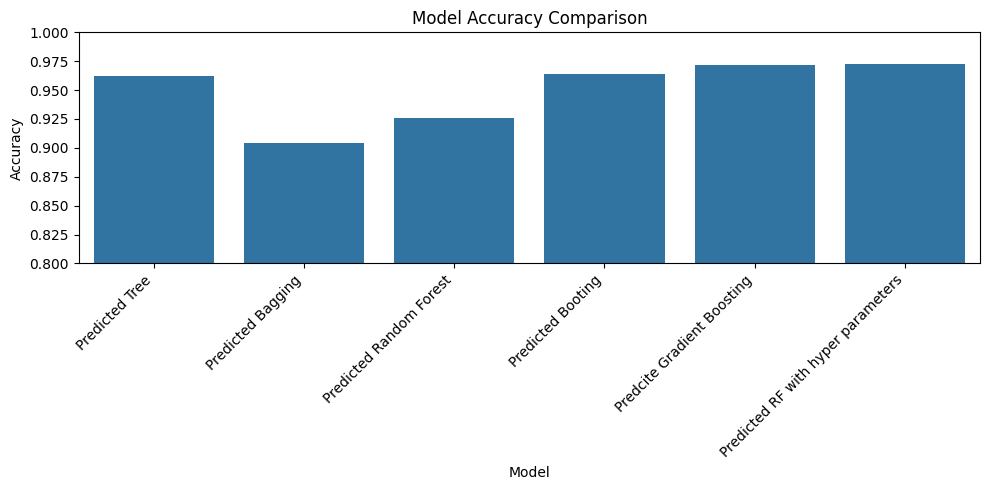

In [58]:
import seaborn as sns

# Add a column for correct prediction per model
model_cols = [
    'Predicted Tree',
    'Predicted Bagging',
    'Predicted Random Forest',
    'Predicted Booting',
    'Predcite Gradient Boosting',
    'Predicted RF with hyper parameters'
]

accuracy_per_model = {
    model: (results_df['Actual'] == results_df[model]).mean()
    for model in model_cols
}

# Convert to DataFrame for plotting
acc_df = pd.DataFrame.from_dict(accuracy_per_model, orient='index', columns=['Accuracy'])

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=acc_df.index, y='Accuracy', data=acc_df)
plt.xticks(rotation=45, ha='right')
plt.ylim(0.8, 1.0)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.tight_layout()
plt.show()

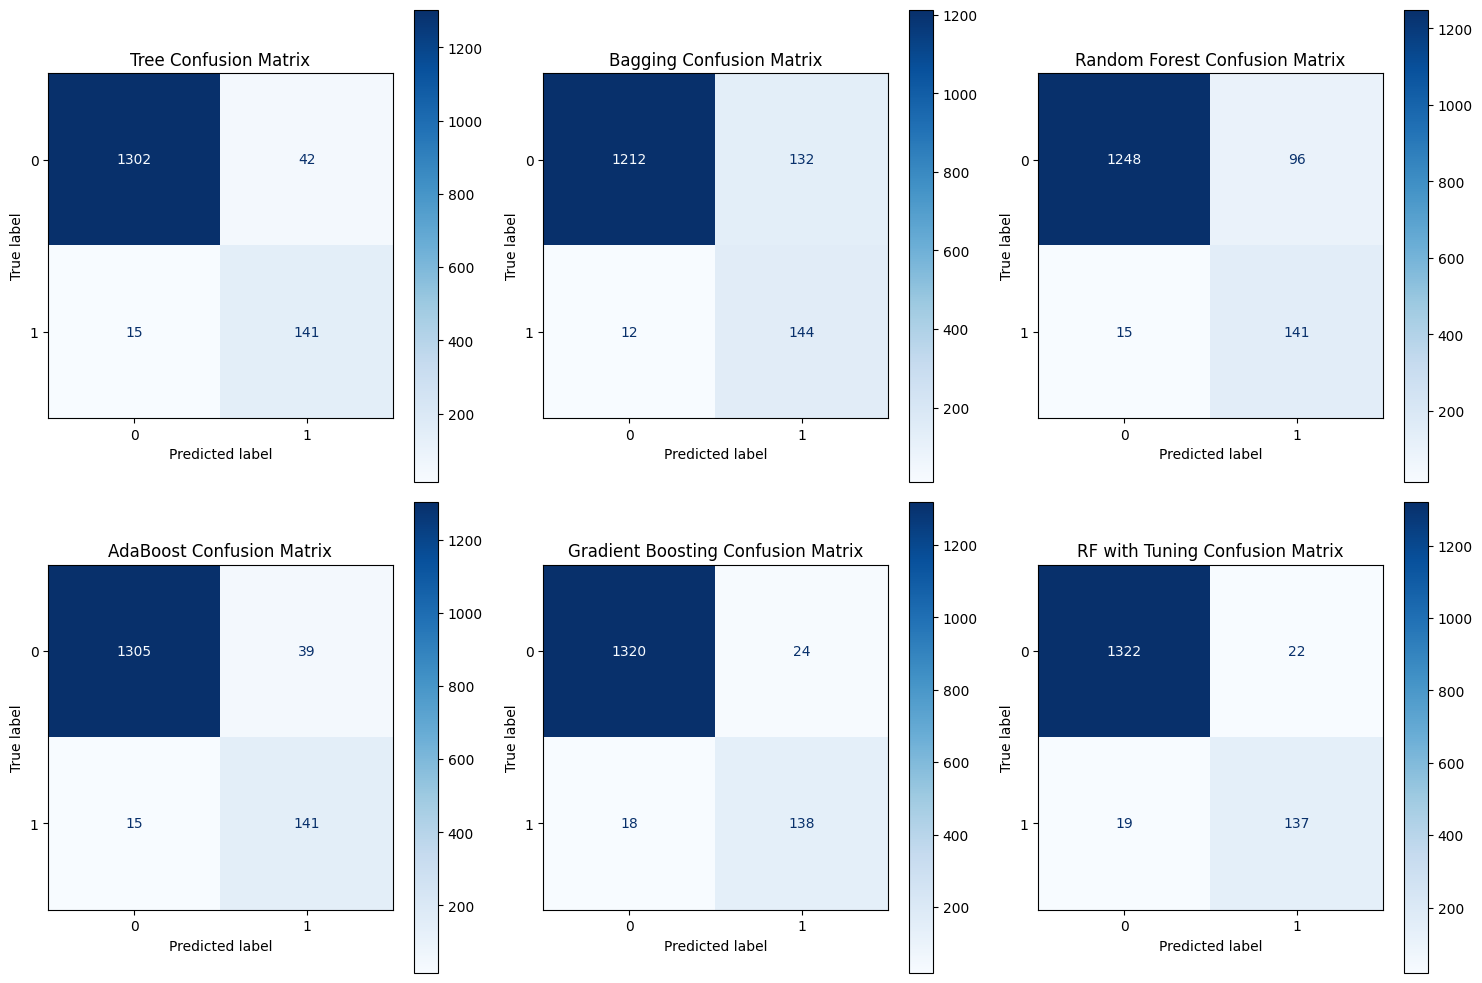

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay

models_preds = {
    'Tree': y_pred_single,
    'Bagging': y_pred_bag,
    'Random Forest': y_pred_rf,
    'AdaBoost': y_pred_ada_clf,
    'Gradient Boosting': y_pred_gb,
    'RF with Tuning': y_pred_rf_hyper
}

plt.figure(figsize=(15, 10))

for i, (name, pred) in enumerate(models_preds.items(), 1):
    plt.subplot(2, 3, i)
    ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=plt.gca(), cmap='Blues')
    plt.title(f'{name} Confusion Matrix')

plt.tight_layout()
plt.show()